# 04. Цепи Маркова

**Статус:** завершено

В этом ноутбуке мы изучаем дискретные цепи Маркова: марковское свойство, матрицу переходов, многошаговые вероятности, стационарное распределение, эргодичность, поглощение и простую модель рыночных режимов.

## Теория и интуиция

Цепь Маркова — это последовательность случайных состояний $X_0,X_1,X_2,\dots$, где будущее зависит от прошлого только через текущее состояние:

$$
\mathbb{P}(X_{n+1}=j\mid X_n=i, X_{n-1},\dots,X_0)=\mathbb{P}(X_{n+1}=j\mid X_n=i)=p_{ij}.
$$

Матрица $P=(p_{ij})$ называется матрицей переходных вероятностей. Каждая строка — распределение следующего состояния при фиксированном текущем состоянии, поэтому

$$
p_{ij}\ge 0, \qquad \sum_j p_{ij}=1.
$$

Если начальное распределение записать строкой $\pi_0$, то распределение через $n$ шагов равно

$$
\pi_n = \pi_0 P^n.
$$

Стационарное распределение $\pi$ удовлетворяет

$$
\pi P = \pi, \qquad \sum_i \pi_i=1.
$$

Интуитивно это долгосрочная доля времени, которую эргодическая цепь проводит в каждом состоянии.

## Импорты и функции

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.markov_chains import (
    calculate_absorbing_chain_absorption_probabilities_and_expected_times,
    calculate_distribution_after_each_step,
    calculate_n_step_transition_matrix,
    calculate_stationary_distribution_for_finite_markov_chain,
    calculate_state_frequencies_over_time,
    calculate_total_variation_distances_to_stationarity,
    plot_manual_markov_chain_graph,
    plot_markov_chain_sample_path,
    plot_markov_chain_transition_matrix_heatmap,
    plot_markov_modulated_cumulative_returns,
    plot_state_frequencies_and_theoretical_distributions,
    plot_total_variation_distance_to_stationarity,
    simulate_markov_modulated_returns,
    simulate_multiple_markov_chain_paths,
)

## 1. Матрица переходов и граф состояний

Рассмотрим три состояния рыночного режима: `Рост`, `Боковик`, `Стресс`. Большие диагональные элементы означают инерционность режима: если рынок уже в данном состоянии, он часто остаётся там ещё один шаг.

,Рост,Боковик,Стресс
Рост,0.86,0.10,0.04
Боковик,0.22,0.62,0.16
Стресс,0.10,0.24,0.66


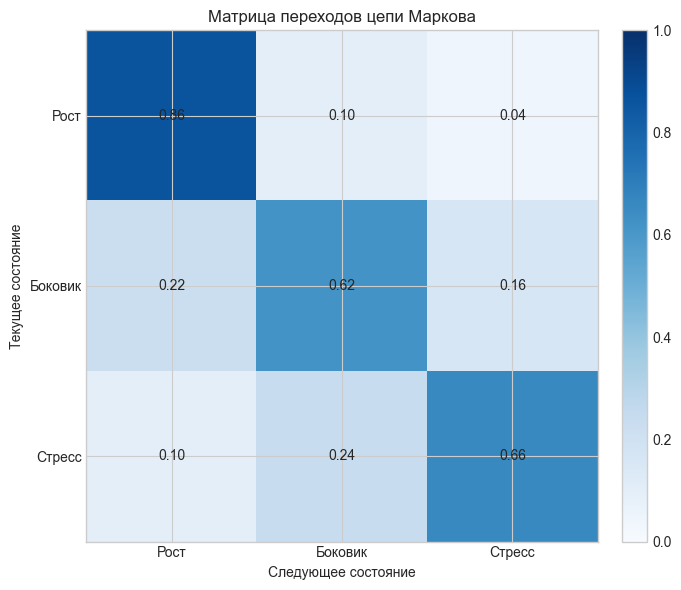

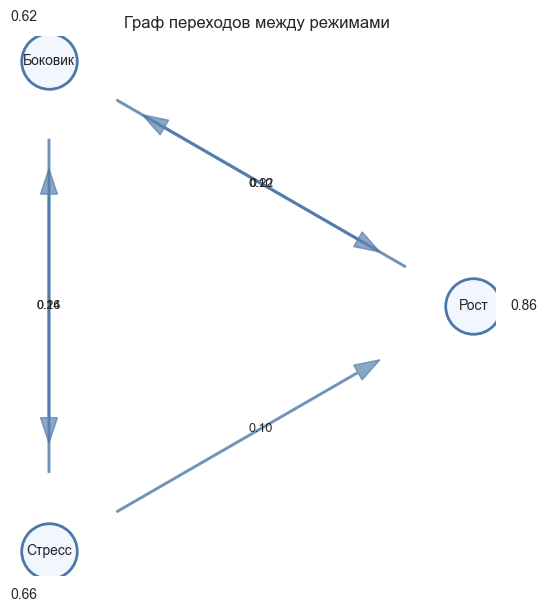

In [2]:
state_names = ["Рост", "Боковик", "Стресс"]
transition_matrix = np.array(
    [
        [0.86, 0.10, 0.04],
        [0.22, 0.62, 0.16],
        [0.10, 0.24, 0.66],
    ]
)

plot_markov_chain_transition_matrix_heatmap(
    transition_matrix=transition_matrix,
    state_names=state_names,
    title="Матрица переходов цепи Маркова",
);
plot_manual_markov_chain_graph(
    transition_matrix=transition_matrix,
    state_names=state_names,
    title="Граф переходов между режимами",
);

pd.DataFrame(transition_matrix, index=state_names, columns=state_names)

Матрица показывает локальные правила движения. Например, из состояния `Рост` цепь остаётся в `Росте` с вероятностью `0.86`, переходит в `Боковик` с вероятностью `0.10` и в `Стресс` с вероятностью `0.04`.

Граф помогает увидеть структуру: все состояния сообщаются друг с другом, то есть из любого режима можно попасть в любой другой за конечное число шагов с положительной вероятностью. Такая цепь является неразложимой. Положительные диагональные вероятности также убирают периодичность, поэтому можно ожидать сходимость к стационарному распределению.

## 2. Одна траектория и марковское свойство

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
Первые 20 состояний,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Рост,Стресс,Стресс,Стресс,Боковик,Стресс,Боковик,Боковик,Боковик


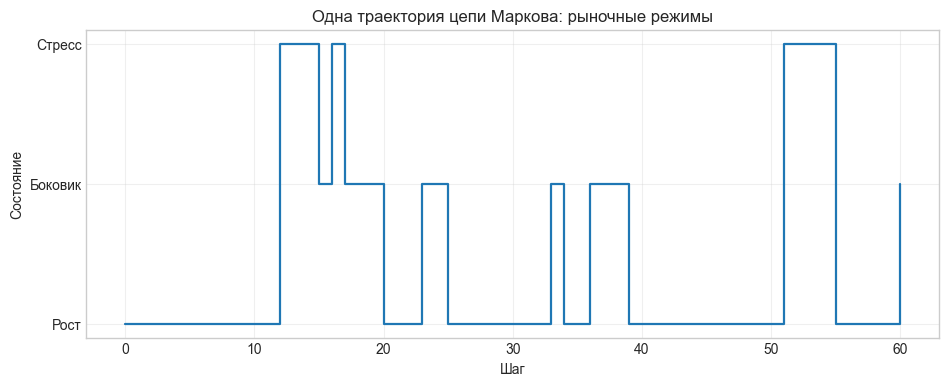

In [3]:
markov_paths = simulate_multiple_markov_chain_paths(
    transition_matrix=transition_matrix,
    initial_state=0,
    number_of_steps=60,
    number_of_paths=5000,
    random_seed=123,
)

plot_markov_chain_sample_path(
    simulated_path=markov_paths[0],
    state_names=state_names,
    title="Одна траектория цепи Маркова: рыночные режимы",
);

pd.DataFrame(
    {"Первые 20 состояний": [state_names[state] for state in markov_paths[0, :20]]}
).T

Одна траектория выглядит как серия периодов, в которых режим сохраняется, а затем иногда переключается. Это следствие больших диагональных вероятностей. Важно, что цепь не помнит, как долго она находится в текущем состоянии: в простой марковской модели вероятность следующего состояния зависит только от текущего режима.

Это одновременно сила и ограничение модели. Она компактна и интерпретируема, но если реальные длительности режимов имеют более сложную структуру, может понадобиться расширение: скрытые марковские модели, полу-марковские процессы или добавление состояния «возраста режима».

## 3. Многошаговые переходы и сходимость к стационарности

Проверим формулу $\pi_n=\pi_0P^n$ на симуляции множества траекторий. Начинаем из состояния `Рост`, то есть $\pi_0=(1,0,0)$.

,Состояние,Стационарная вероятность,Теория на шаге 10,Теория на шаге 60,Симуляция на шаге 60
0,Рост,0.5483,0.5618,0.5483,0.5502
1,Боковик,0.2633,0.2575,0.2633,0.2604
2,Стресс,0.1884,0.1807,0.1884,0.1894


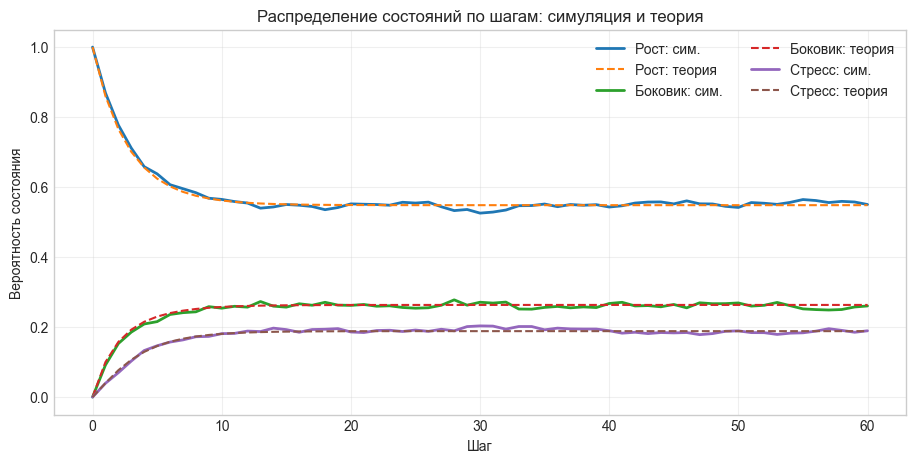

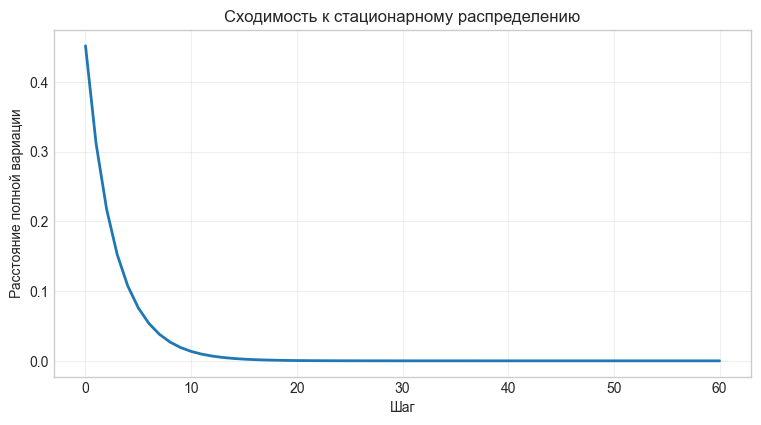

In [4]:
initial_distribution = np.array([1.0, 0.0, 0.0])
theoretical_distributions = calculate_distribution_after_each_step(
    initial_distribution=initial_distribution,
    transition_matrix=transition_matrix,
    number_of_steps=60,
)
empirical_state_frequencies = calculate_state_frequencies_over_time(
    simulated_paths=markov_paths,
    number_of_states=3,
)
stationary_distribution = calculate_stationary_distribution_for_finite_markov_chain(transition_matrix)
total_variation_distances = calculate_total_variation_distances_to_stationarity(
    distributions=theoretical_distributions,
    stationary_distribution=stationary_distribution,
)

plot_state_frequencies_and_theoretical_distributions(
    empirical_frequencies=empirical_state_frequencies,
    theoretical_distributions=theoretical_distributions,
    state_names=state_names,
    title="Распределение состояний по шагам: симуляция и теория",
);
plot_total_variation_distance_to_stationarity(
    total_variation_distances=total_variation_distances,
    title="Сходимость к стационарному распределению",
);

pd.DataFrame(
    {
        "Состояние": state_names,
        "Стационарная вероятность": stationary_distribution,
        "Теория на шаге 10": theoretical_distributions[10],
        "Теория на шаге 60": theoretical_distributions[60],
        "Симуляция на шаге 60": empirical_state_frequencies[60],
    }
)

In [5]:
power_five_transition_matrix = calculate_n_step_transition_matrix(
    transition_matrix=transition_matrix,
    number_of_steps=5,
)

pd.DataFrame(
    power_five_transition_matrix,
    index=state_names,
    columns=state_names,
)

,Рост,Боковик,Стресс
Рост,0.6242,0.2299,0.1459
Боковик,0.4858,0.2974,0.2168
Стресс,0.4149,0.3127,0.2724


Стационарное распределение получилось примерно `(0.5483, 0.2633, 0.1884)`. Это означает, что в долгосрочном режиме цепь проводит около 55% времени в `Росте`, 26% в `Боковике` и 19% в `Стрессе`.

На шаге `10` теоретическое распределение уже близко к стационарному: `(0.5618, 0.2575, 0.1807)`. На шаге `60` оно практически совпадает со стационарным, а симуляция дала `(0.5502, 0.2604, 0.1894)`. Расстояние полной вариации падает с `0.4517` на шаге 0 до `0.0135` на шаге 10 и почти до нуля на шаге 60.

Матрица $P^5$ показывает вероятности через пять шагов. Например, начиная из `Роста`, через 5 шагов вероятность всё ещё быть в `Росте` около `0.6242`, но уже есть заметные шансы оказаться в `Боковике` (`0.2299`) или `Стрессе` (`0.1459`).

## 4. Когда стационарность не означает сходимость

Стационарное распределение может существовать даже у цепи, которая не сходится к нему из конкретного начального состояния. Простейший пример — периодическая цепь с двумя состояниями:

$$
P=\begin{pmatrix}0&1\\1&0\end{pmatrix}.
$$

Она каждый шаг строго переключается между состояниями. Стационарное распределение равно `(0.5, 0.5)`, но распределение из состояния 0 будет вечно колебаться.

In [6]:
periodic_transition_matrix = np.array([[0.0, 1.0], [1.0, 0.0]])
periodic_initial_distribution = np.array([1.0, 0.0])
periodic_distributions = calculate_distribution_after_each_step(
    initial_distribution=periodic_initial_distribution,
    transition_matrix=periodic_transition_matrix,
    number_of_steps=8,
)
periodic_stationary_distribution = calculate_stationary_distribution_for_finite_markov_chain(
    periodic_transition_matrix
)

pd.DataFrame(
    periodic_distributions,
    columns=["Состояние 0", "Состояние 1"],
).assign(Шаг=np.arange(9)).set_index("Шаг"), periodic_stationary_distribution

(     Состояние 0  Состояние 1
 Шаг                          
 0            1.0          0.0
 1            0.0          1.0
 2            1.0          0.0
 3            0.0          1.0
 4            1.0          0.0
 5            0.0          1.0
 6            1.0          0.0
 7            0.0          1.0
 8            1.0          0.0,
 array([0.5, 0.5]))

Эта маленькая таблица показывает полезную тонкость: стационарное распределение — это распределение, которое не меняется после умножения на $P$, но не всякая цепь из любого старта к нему сходится. Для сходимости обычно нужны неразложимость и апериодичность. В нашей цепи рыночных режимов эти условия выполняются благодаря сообщающимся состояниям и положительным вероятностям остаться на месте.

## 5. Поглощающая цепь

Поглощающая цепь содержит состояния, из которых уже нельзя выйти. Например, клиент может перейти в состояние `Успех` или `Отказ`, и оба состояния финальные.

Для transient-состояний фундаментальная матрица

$$
F=(I-Q)^{-1}
$$

показывает ожидаемое число посещений transient-состояний до поглощения. Матрица $FR$ даёт вероятности поглощения в каждое absorbing-состояние.

(                   Вероятность успеха  Вероятность отказа
 Старт: Лид                     0.6933              0.3067
 Старт: Переговоры              0.7067              0.2933,
                    Ожидаемое время до поглощения
 Старт: Лид                                4.5333
 Старт: Переговоры                         3.4667)

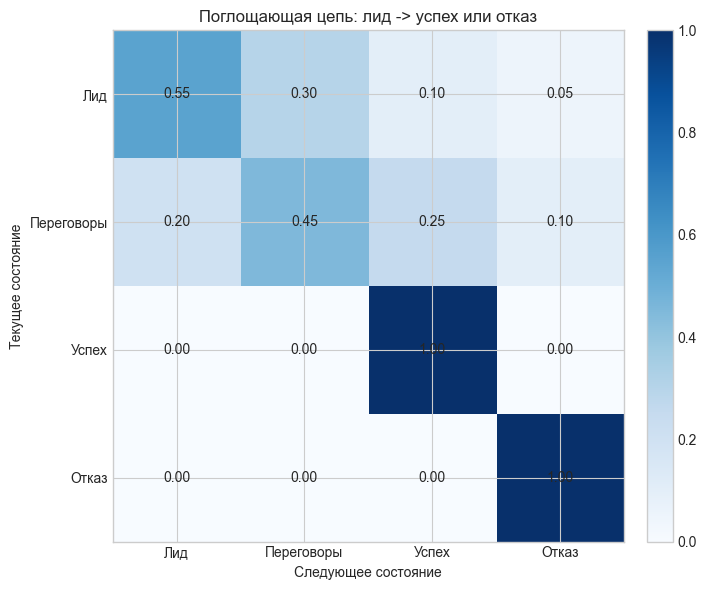

In [7]:
absorbing_state_names = ["Лид", "Переговоры", "Успех", "Отказ"]
absorbing_transition_matrix = np.array(
    [
        [0.55, 0.30, 0.10, 0.05],
        [0.20, 0.45, 0.25, 0.10],
        [0.00, 0.00, 1.00, 0.00],
        [0.00, 0.00, 0.00, 1.00],
    ]
)
fundamental_matrix, absorption_probabilities, expected_absorption_times = calculate_absorbing_chain_absorption_probabilities_and_expected_times(
    transition_matrix=absorbing_transition_matrix,
    transient_state_indices=[0, 1],
    absorbing_state_indices=[2, 3],
)

plot_markov_chain_transition_matrix_heatmap(
    transition_matrix=absorbing_transition_matrix,
    state_names=absorbing_state_names,
    title="Поглощающая цепь: лид -> успех или отказ",
);

pd.DataFrame(
    absorption_probabilities,
    index=["Старт: Лид", "Старт: Переговоры"],
    columns=["Вероятность успеха", "Вероятность отказа"],
), pd.DataFrame(
    {"Ожидаемое время до поглощения": expected_absorption_times},
    index=["Старт: Лид", "Старт: Переговоры"],
)

Если стартовать из `Лида`, вероятность в итоге прийти к `Успеху` равна примерно `0.6933`, а к `Отказу` — `0.3067`. Если стартовать из `Переговоров`, вероятность успеха чуть выше: `0.7067`.

Ожидаемое время до поглощения равно `4.5333` шага из `Лида` и `3.4667` шага из `Переговоров`. Это отражает структуру процесса: из стадии переговоров путь до финального решения в среднем короче.

## 6. Марковская модель рыночных режимов

Теперь используем состояния как скрытые режимы доходности. В каждом режиме доходность имеет своё среднее и волатильность: `Рост` — умеренно положительное среднее, `Боковик` — около нуля, `Стресс` — отрицательное среднее и высокая волатильность.

,Показатель,Значение
0,Средняя итоговая доходность,0.0474
1,Стандартное отклонение,0.2238
2,Доля отрицательных итогов,0.4080


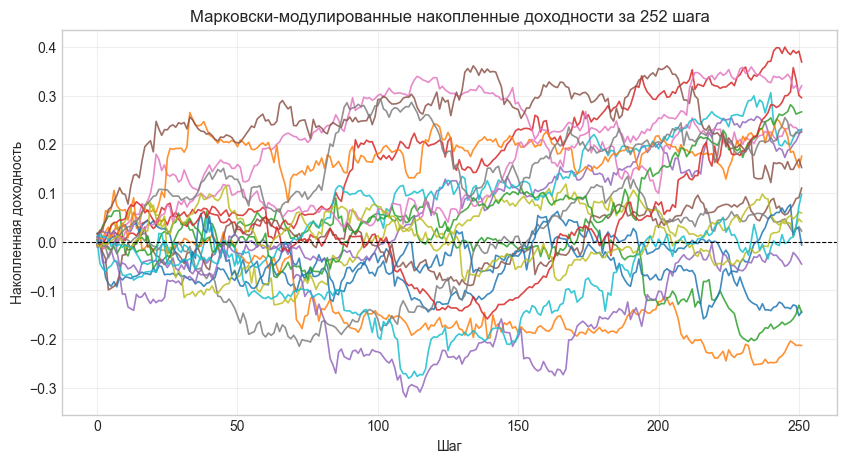

In [8]:
state_paths, simulated_returns, cumulative_returns = simulate_markov_modulated_returns(
    transition_matrix=transition_matrix,
    state_means=np.array([0.001, 0.000, -0.002]),
    state_volatilities=np.array([0.008, 0.012, 0.025]),
    initial_state=0,
    number_of_steps=252,
    number_of_paths=3000,
    random_seed=321,
)

plot_markov_modulated_cumulative_returns(
    cumulative_returns=cumulative_returns,
    number_of_paths_to_plot=20,
    title="Марковски-модулированные накопленные доходности за 252 шага",
);

pd.DataFrame(
    {
        "Показатель": ["Средняя итоговая доходность", "Стандартное отклонение", "Доля отрицательных итогов"],
        "Значение": [
            cumulative_returns[:, -1].mean(),
            cumulative_returns[:, -1].std(),
            np.mean(cumulative_returns[:, -1] < 0.0),
        ],
    }
)

Средняя итоговая доходность за 252 шага получилась `0.0474`, стандартное отклонение `0.2238`, а доля отрицательных итогов `0.4080`. Даже при положительной долгосрочной средней доходности риск остаётся существенным, потому что цепь иногда попадает в стрессовый режим с высокой волатильностью.

Смысл такой модели не в точном прогнозе рынка, а в разделении двух источников случайности: переключение режима и шум доходности внутри режима. Это простая, но очень полезная конструкция для сценарного анализа.

## Основные выводы

1. Марковское свойство означает, что для прогноза следующего состояния достаточно знать текущее состояние.
2. Матрица переходов задаёт локальные правила, а степени $P^n$ дают многошаговые вероятности.
3. Стационарное распределение описывает долгосрочные доли времени в состояниях, но сходимость к нему требует дополнительных условий вроде апериодичности.
4. Расстояние полной вариации удобно показывает скорость забывания начального состояния.
5. Поглощающие цепи позволяют считать вероятности финальных исходов и ожидаемое время до них через фундаментальную матрицу.
6. Марковские режимы полезны для прикладных моделей, где параметры наблюдаемого процесса меняются вместе со скрытым состоянием.